In [ ]:
!pip install -q transformers datasets
!pip install mtcnn
!pip install tensorflow
!pip install lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.0 MB/s eta 0:00:00


In [1]:
from datasets import load_dataset
import tensorflow as tf
from transformers import ViTImageProcessor, TFViTModel
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = load_dataset("tonyassi/celebrity-1000", split="train")

selected_old_ids = range(10)
print("Original label IDs used:", selected_old_ids)
print("Total images before filtering:", len(dataset))

def filter_10(example):
    return example["label"] in selected_old_ids

dataset = dataset.filter(filter_10)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18184 [00:00<?, ? examples/s]

Original label IDs used: range(0, 10)
Total images before filtering: 18184


Filter:   0%|          | 0/18184 [00:00<?, ? examples/s]

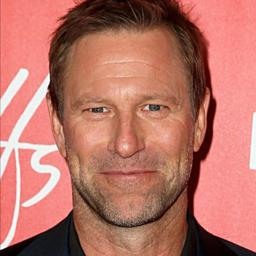

In [12]:
dataset[0]['image']

In [4]:
print(len(selected_old_ids))

10


In [16]:
dataset.shape

(160, 2)

In [6]:
from transformers import ViTImageProcessor

MODEL_NAME = "google/vit-base-patch16-224-in21k"

embedder = TFViTModel.from_pretrained(MODEL_NAME, from_pt=True)

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [7]:
print(processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [27]:
embedder.config

ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "transformers_version": "4.57.3"
}

In [ ]:
def preprocess(batch):
    processed_image = processor(images=batch["image"], return_tensors="np")
    return {"pixel_values": processed_image["pixel_values"]}

In [ ]:
dataset = dataset.map(preprocess, batched=True)

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

In [ ]:
dataset

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 160
})

In [ ]:
ds = dataset.with_format("tensorflow")
tf_ds = dataset.to_tf_dataset(
    columns=["pixel_values"],
    label_cols=["label"],
    batch_size=64,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [ ]:
all_embeddings = []

for batch, labels in tf_ds:
    outputs = embedder(batch)
    emb = outputs.pooler_output
    all_embeddings.append(emb)

In [ ]:
all_embeddings = np.concatenate(all_embeddings,axis=0)
all_embeddings.shape

(160, 768)

In [ ]:
emb_list = [emb for emb in all_embeddings]
dataset = dataset.add_column("embedding", emb_list)

In [ ]:
ds=dataset.remove_columns(['pixel_values',"image"])
ds

Dataset({
    features: ['label', 'embedding'],
    num_rows: 160
})

Load & split celebrity-1000 (70/10/20)

In [ ]:
dataset_shuffled = ds.shuffle(seed=42)

train_temp = dataset_shuffled.train_test_split(test_size=0.30, seed=42, stratify_by_column='label')
train_ds = train_temp["train"]
temp_ds  = train_temp["test"]

val_test = temp_ds.train_test_split(test_size=2/3, seed=42)
val_ds = val_test["train"]
test_ds = val_test["test"]

num_classes = len(selected_old_ids)

In [ ]:
train_ds.shape

(112, 2)

In [ ]:
x_train = np.array(train_ds["embedding"])
y_train = np.array(train_ds["label"])
x_val = np.array(val_ds["embedding"])
y_val = np.array(val_ds["label"])
x_test = np.array(test_ds["embedding"])
y_test = np.array(test_ds["label"])

In [ ]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Input(shape=(768,)),
    # layers.Dense(256, activation='relu'),
    # layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,722 (389.54 KB)

 Trainable params: 99,722 (389.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 902ms/step - accuracy: 0.1061 - loss: 2.3701 - val_accuracy: 0.5625 - val_loss: 1.7848
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5158 - loss: 1.7290 - val_accuracy: 0.6875 - val_loss: 1.4531
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7161 - loss: 1.3314 - val_accuracy: 0.7500 - val_loss: 1.1673
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7952 - loss: 1.0087 - val_accuracy: 0.8750 - val_loss: 0.9946
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8368 - loss: 0.8017 - val_accuracy: 0.8750 - val_loss: 0.8520
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8418 - loss: 0.6859 - val_accuracy: 0.9375 - val_loss: 0.7181
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9174 - loss: 0.5362 - val_accuracy: 0.8750 - val_loss: 0.6380
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9024 - loss: 0.4979 - val_accuracy: 0.9375 - val_loss: 0.5560

We’ll also update the classifier label mapping:

In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step - accuracy: 0.7812 - loss: 0.6338
Accuracy: 0.78125


In [ ]:
import tensorflow as tf

def preprocess_input_image(img):
    # Convert PIL → model tensor
    inputs = processor(images=img, return_tensors="tf")
    tensor_img = inputs["pixel_values"]

    # Additional normalization and enhancement
    tensor_img = tf.image.per_image_standardization(tensor_img)

    return tensor_img


In [ ]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(224, 224)):

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face

In [ ]:
import numpy as np
import tensorflow as tf

def get_prediction(img_pil, top_k=None):
    tensor_img = preprocess_input_image(img_pil)
    outputs = embedder(tensor_img)
    emb = outputs.pooler_output   # (batch, 768)

    preds = model.predict(emb)    # (1, num_classes)
    preds = np.asarray(preds)

    if preds.ndim == 2 and preds.shape[0] == 1:
        scores = preds[0]
    else:
        scores = preds.ravel()

    s = float(np.sum(scores))
    if abs(s - 1.0) < 1e-3 and np.all(scores >= 0):

        probs = scores
        used_softmax = False
    else:

        probs = tf.nn.softmax(scores).numpy()
        used_softmax = True

    predicted_class = int(np.argmax(scores))
    predicted_prob = float(probs[predicted_class]) * 100.0
    print("\n=== Prediction summary ===")
    print(f"Softmax applied: {used_softmax}")
    print(f"Predicted Class Index: {predicted_class}")
    try:
        name = dataset.features['label'].names[predicted_class]
    except Exception:
        name = str(predicted_class)
    print(f"Name: {name}")
    print(f"Confidence: {predicted_prob:.2f}%")

    sorted_indices = np.argsort(probs)[::-1]
    if top_k is not None:
        sorted_indices = sorted_indices[:top_k]
    print("\nClasses (sorted by probability):")
    for rank, idx in enumerate(sorted_indices, start=1):
        try:
            cls_name = dataset.features['label'].names[int(idx)]
        except Exception:
            cls_name = str(int(idx))
        conf = probs[int(idx)] * 100.0
        print(f"{rank:02d}. Index: {int(idx):3d}  Name: {cls_name:20s}  Confidence: {conf:6.2f}%")

    return scores, probs, sorted_indices


In [ ]:
dataset.features['label'].names[:10]

['Aaron Eckhart',
 'Aaron Paul',
 'Aaron Rodgers',
 'Aaron Taylor-Johnson',
 'Abbi Jacobson',
 'Abhishek Bachchan',
 'Abigail Breslin',
 'Abigail Spencer',
 'Adam Brody',
 'Adam Devine']

Saving Aaron Paul.webp to Aaron Paul.webp


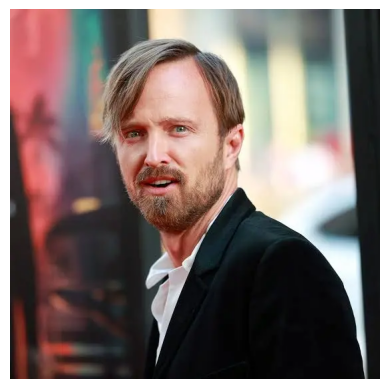

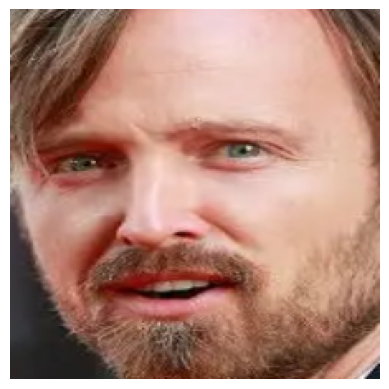

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

=== Prediction summary ===
Softmax applied: False
Predicted Class Index: 1
Name: Aaron Paul
Confidence: 43.97%

Classes (sorted by probability):
01. Index:   1  Name: Aaron Paul            Confidence:  43.97%
02. Index:   5  Name: Abhishek Bachchan     Confidence:  15.12%
03. Index:   2  Name: Aaron Rodgers         Confidence:  12.38%
04. Index:   3  Name: Aaron Taylor-Johnson  Confidence:  10.84%
05. Index:   8  Name: Adam Brody            Confidence:   6.80%
06. Index:   0  Name: Aaron Eckhart         Confidence:   6.63%
07. Index:   4  Name: Abbi Jacobson         Confidence:   1.44%
08. Index:   9  Name: Adam Devine           Confidence:   1.42%
09. Index:   6  Name: Abigail Breslin       Confidence:   0.94%
10. Index:   7  Name: Abigail Spencer       Confidence:   0.46%


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = Image.open(filename).convert("RGB")
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)
if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
  get_prediction(cropped)